In [38]:
import pandas as pd
train =pd.read_csv("./drive/MyDrive/TechAxis/Datasets/mnist_train.csv")
test =pd.read_csv("./drive/MyDrive/TechAxis/Datasets/mnist_test.csv")

In [39]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
y_train=train["label"]
x_train=train.drop(labels=["label"],axis=1)

In [41]:
y_train.value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [42]:
x_train=x_train/255.0
test=test/255.0

In [43]:
x_train=x_train.values.reshape(-1,28,28,1)
test=test.values.reshape(-1,28,28,1)

In [44]:
from keras.utils import to_categorical
y_train=to_categorical(y_train,num_classes=10)

In [45]:
from sklearn .model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.1)

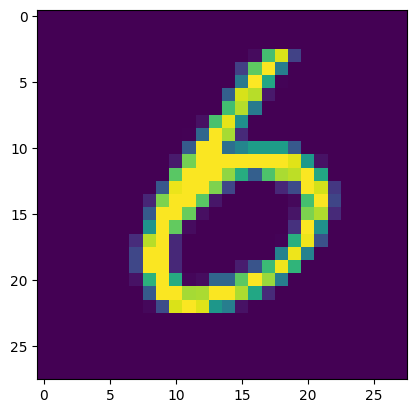

In [46]:
import matplotlib.pyplot as plt
g=plt.imshow(x_train[1][:,:,0])

In [47]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D


model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', activation ='relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
from keras.optimizers import RMSprop
optimizer = RMSprop(learning_rate=0.001,rho=0.9,epsilon=1e-08,decay=0.0)

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [49]:
model.compile(optimizer,loss="categorical_crossentropy",metrics=["accuracy"])


In [50]:
history=model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=5,
    validation_data=(x_val,y_val)
)

Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7999 - loss: 0.6005 - val_accuracy: 0.9719 - val_loss: 0.0931
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9759 - loss: 0.0794 - val_accuracy: 0.9843 - val_loss: 0.0517
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9834 - loss: 0.0546 - val_accuracy: 0.9848 - val_loss: 0.0485
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9878 - loss: 0.0419 - val_accuracy: 0.9881 - val_loss: 0.0463
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9878 - loss: 0.0389 - val_accuracy: 0.9879 - val_loss: 0.0406


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


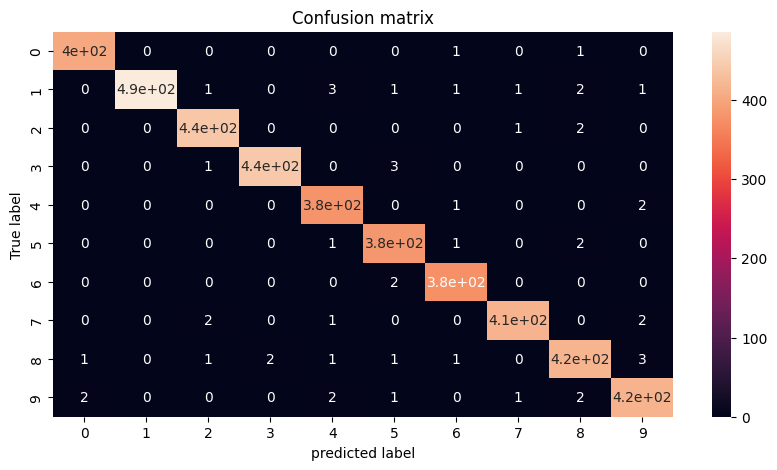

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred=model.predict(x_val)
y_pred_classes=np.argmax(y_pred,axis=1)
y_true=np.argmax(y_val,axis=1)
cm=confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(10,5))
sns.heatmap(cm,annot= True)
plt.xlabel("predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix")
plt.show()